<hr>

# Welcome to Week 3
### Unsupervised learning
<hr>

In [1]:
import warnings
warnings.filterwarnings("ignore")

#### Clustering Algorithms
Clustering puts data points into groups. It uses similarity and difference of features (or dimensions) to create groups in material that is unclassified and has no known targets. It’s particularly used in unsupervised learning as it can deal with vast amounts of uncategorised data however it creates groups so it’s useful in supervised learning as well. 

<hr>

<img src="figure/Clustering and its applications image 2.png"
     alt="Markdown Monster icon"
     style="float: left; margin-right: 10px;" />
     
 <br>
 


Figure. Patterns in the sky (Susan, 2015)<br>
Yes you did! Our brains always look for patterns!

Why do we see patterns in the clouds? The traditional explanation is that it was very important to in individual’s survival to spot a jaguar in the undergrowth. Our brains cluster unconsciously. In fact, we are encoded to see patterns in everything such as shopping, traffic, clothes, sport etc.

<hr>

***The goal of clustering algorithms are to:***

- Group unlabelled data objects with similar properties together
- Discover interesting perhaps unexpected clusters in the data
- Find a valid or useful organisation of the data
<br>
In other words, we can define two algorithmic goals. We need to find objective functions to:

- Minimise intra-distance (distance between points in the same cluster)
- Maximise inter-distance (distance between points from different clusters)

<img src="figure/Clustering and its applications image 3.png"
     alt="Markdown Monster icon"
     style="float: left; margin-right: 10px;" />

<hr>

### popular clustering methods are as follow:
1. KMeans
2. DBscan
3. Hierarchical 
4. KMeans++
5. VAT
6. IVAT

<hr>

<hr>

### Distance
Clustering between two groups is measured by distance metrics.
Types of distance measurements:

---

- **Euclidean distance**
 The ordinary straight-line distance between two points in Euclidean (everyday) space. For any two data instances, represented by d-dimensional feature vectors $x_i,x_j$  their Euclidean distance is computed as: <br>
### $d_{Euclidean}(x_i,x_j)=\sqrt{(x_{i,1}-x_{j,2})^2+...+(x_{d,1}-x_{d,2})^2}$

```python
from scipy.spatial.distance import euclidean
euclidean([1, 2, 3], [4, 6, 3])  # = 5.0
```

---

- **Cosine distance**
We previously introduced cosine distance in course 1. But as a reminder, we define Cosine distance for any two data instances represented by d-dimensional feature vectors. The Cosine distance for these two feature vectors $x_i,x_j$ is computed as:<br>
### $d_{cosine}(x_i,x_j)=1-\frac{x_i^Tx_j}{||x_i||_2.||x_j||_2}$

```python
from scipy.spatial.distance import cosine
cosine([1, 2, 3], [4, 6, 3])  # = 0.0822
```

---

- **Cityblock/Manhattan distance**
For any two data instances, represented by d-dimensional feature vectors $x_i,x_j$, their Cityblock distance is computed as:<br>
### $d_{Cityblock}(x_i,x_j)=|x_{i,1}-x_{j,2}|+...+|x_{d,1}-x_{d,2})|$

```python
from scipy.spatial.distance import cityblock
cityblock([1, 2, 3], [4, 6, 3])  # = 7
```

---

- **Minkowski distance**
 A generalisation of Euclidean and Manhattan distances for any p-norm. Think of Euclidean distance (2 norm of $x_{i}-x_{j}$) and Cityblock distance as (1 norm of $x_{i}-x_{j}$).<br>
### $d_{Minkowski}(x_i,x_j)=(\sum_{i=0}^{n-1}|x_i-y_i|^p)^\frac{1}{p}$

    -  When $p=1$, the distance is known as the Manhattan distance.
    -  When $p=2$ the distance is known as the Euclidean distance.

```python
from scipy.spatial.distance import minkowski
minkowski([1, 2, 3], [4, 6, 3], p=1)  # Manhattan = 7
minkowski([1, 2, 3], [4, 6, 3], p=2)  # Euclidean = 5.0
minkowski([1, 2, 3], [4, 6, 3], p=3)  # p=3 norm = 4.497
```

---

- **Jaccard distance**
 A distance used to measure diversity of any two sets. Consider any two instances $x_i$ and $x_j$ as **binary vectors** indicating presence or absence of features. Jaccard distance between $x_i$ and $x_j$ is defined as:<br>
### $d_{Jaccard}(x_i,x_j)=1-\frac{|x_i\cap x_j|_1}{|x_i\cup x_j|_1}$

```python
from scipy.spatial.distance import jaccard
jaccard([1, 1, 0, 1, 0], [1, 0, 0, 1, 1])  # = 0.5
```

More details check week-3 class materials.

#### Hands-on: Calculate Euclidean Distance Step by Step

Before using sklearn, let's make sure we understand how distance is computed manually.

Given two 3-dimensional data points:
- $x_1 = [1, 2, 3]$
- $x_2 = [4, 6, 3]$

**Euclidean distance:**

$$d(x_1, x_2) = \sqrt{(1-4)^2 + (2-6)^2 + (3-3)^2} = \sqrt{9 + 16 + 0} = \sqrt{25} = 5$$

Run the cell below to verify this, then try changing the values to see how the distance changes.

In [2]:
import numpy as np

# Two data points
x1 = np.array([1, 2, 3])
x2 = np.array([4, 6, 3])

# Step-by-step Euclidean distance
diff = x1 - x2                        # Step 1: subtract
print("Step 1 - Difference:", diff)

squared = diff ** 2                    # Step 2: square each
print("Step 2 - Squared:   ", squared)

summed = np.sum(squared)               # Step 3: sum
print("Step 3 - Sum:       ", summed)

distance = np.sqrt(summed)             # Step 4: square root
print("Step 4 - Distance:  ", distance)

# Verify with scipy
from scipy.spatial.distance import euclidean
print("\nScipy verification: ", euclidean(x1, x2))

Step 1 - Difference: [-3 -4  0]
Step 2 - Squared:    [ 9 16  0]
Step 3 - Sum:        25
Step 4 - Distance:   5.0

Scipy verification:  5.0


#### Your Turn: Compare Different Distance Metrics

Calculate the **Manhattan** and **Cosine** distance for the same two points. Fill in the code below.

In [3]:
from scipy.spatial.distance import cityblock, cosine

x1 = np.array([1, 2, 3])
x2 = np.array([4, 6, 3])

# Manhattan distance: sum of absolute differences
manhattan = np.sum(np.abs(x1 - x2))
print("Manhattan distance:", manhattan)

# Cosine distance: 1 - (dot product) / (norm_x1 * norm_x2)
cosine_dist = 1 - np.dot(x1, x2) / (np.linalg.norm(x1) * np.linalg.norm(x2))
print("Cosine distance:   ", cosine_dist)

# Verify with scipy
print("\nScipy Manhattan:", cityblock(x1, x2))
print("Scipy Cosine:   ", cosine(x1, x2))

Manhattan distance: 7
Cosine distance:    0.14451761146355635

Scipy Manhattan: 7
Scipy Cosine:    0.14451761146355635


#### All Distance Metrics at a Glance

The table below computes all distance metrics discussed above for the same pair of points. Notice how different metrics give different values -- this is why the choice of distance metric matters for clustering.

In [ ]:
from scipy.spatial.distance import euclidean, cityblock, cosine, minkowski, jaccard

x1 = np.array([1, 2, 3])
x2 = np.array([4, 6, 3])

print(f"x1 = {x1}")
print(f"x2 = {x2}")
print(f"{'':->50}")
print(f"{'Euclidean:':<20} {euclidean(x1, x2):.4f}")
print(f"{'Manhattan:':<20} {cityblock(x1, x2):.4f}")
print(f"{'Cosine:':<20} {cosine(x1, x2):.4f}")
print(f"{'Minkowski (p=3):':<20} {minkowski(x1, x2, p=3):.4f}")

# Jaccard needs binary vectors
x1_bin = np.array([1, 1, 0, 1, 0])
x2_bin = np.array([1, 0, 0, 1, 1])
print(f"\nFor Jaccard (binary vectors):")
print(f"x1 = {x1_bin}, x2 = {x2_bin}")
print(f"{'Jaccard:':<20} {jaccard(x1_bin, x2_bin):.4f}")

### KMeans
KMeans is an unsupervised clustring ML model, where the number of clusters is defined by $K$. $K$ is also called the number of neighbours.
<hr>
<img src="figure/kmean.png"
     alt="Markdown Monster icon"
     style="float: left; margin-right: 10px;" />

<hr>

### Let's implemented in Python

In [5]:
import pandas as pd
import numpy as np
digit_zero=pd.read_csv("data/digitData0.csv",header=None)
digit_one=pd.read_csv("data/digitData1.csv",header=None)
digit_zero.shape
digit_zero.head()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,64
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4.0


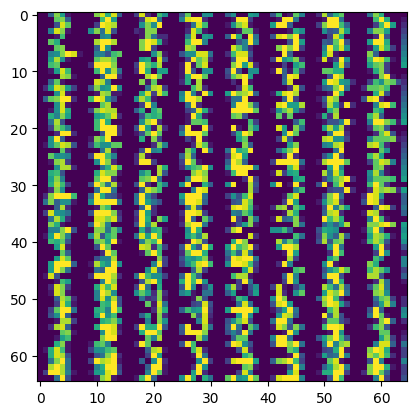

In [6]:
import matplotlib.pyplot as plt
plt.imshow(digit_one.values[0:65,:])

#### Seperating feature set and creating a ground truth for clustering model

In [7]:
Feature_set=pd.concat([digit_zero,digit_one],join="inner")
print(Feature_set.shape)
Feature_set.head()

(3218, 65)


,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,64
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4.0


### Adding feature_header

In [8]:
cols=["feature_"+str(i+1) for i in range(Feature_set.shape[1]-1)]
cols.append("Target")
Feature_set.columns=cols

Feature_set.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,Target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4.0


<hr>

### How to define number of cluter,K?
***Elbow method***
<br>
Elbow method shows the optimum k value from a range of values usingdistence metrics.


`KElbowVisualizer` parameters in that cell:

- `model=KMeans()`: estimator to evaluate.
- `k=(2,12)`: try K=2..12.
- `metric='distortion'`: elbow uses sum of squared distances of samples to nearest centroid (a.k.a. within-cluster SSE, inertia). lower is tighter clusters.
- `timings=False`: don’t plot fitting-time curve.

It fits KMeans on `X` for each k, computes metric, and draws elbow plot; choose k where metric curve bends. `X=Feature_set.iloc[:, :-1]`, `y` unused for clustering labels.

In [9]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

from yellowbrick.cluster import KElbowVisualizer

# Generate synthetic dataset with 8 random clusters
X=Feature_set.iloc[:,0:-1]
y=Feature_set.iloc[:,-1]

# Instantiate the clustering model and visualizer
model = KMeans()
visualizer = KElbowVisualizer(
    model, k=(2,12), metric='distortion', timings=False
) #distortion same as Euclidean distance

visualizer.fit(X)        # Fit the data to the visualizer
visualizer.show()  

ModuleNotFoundError: No module named 'yellowbrick'

#### How to Read the Elbow Plot

The **distortion** metric measures the average squared distance from each point to its assigned cluster centroid. As K increases, distortion always decreases (more clusters = shorter distances).

**How to pick K:**
- Look for the "elbow" -- the point where the curve **bends sharply** and then flattens out.
- Before the elbow: adding more clusters gives a **big improvement**.
- After the elbow: adding more clusters gives **diminishing returns** (not worth the extra complexity).

> Think of it like this: if you have 2 clusters for 10 different digit types, each cluster must contain many different digits (high distortion). At K=10, each cluster can represent one digit (low distortion). But going from K=10 to K=11 doesn't help much -- that's the "elbow".

### KElbowVisualizer Parameters 

- **model = KMeans()**  
  Initializes the K-Means clustering model that will be evaluated for different numbers of clusters.

- **k=(2,12)**  
  Range of cluster values to test. The visualizer will evaluate cluster counts from **2 to 12**.

- **metric='calinski_harabasz'**  
  Metric used to evaluate clustering quality.  
  Higher values indicate better-defined clusters (good separation and compactness).

- **timings=False**  
  Disables the display of computation time for each k value in the plot.

### Methods

- **visualizer.fit(X)**  
  Fits the dataset to the model for each value of k and computes the chosen metric.

- **visualizer.show()**  
  Displays the elbow plot to help identify the optimal number of clusters.

C:\Users\sit\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\sit\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\sit\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\sit\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warning

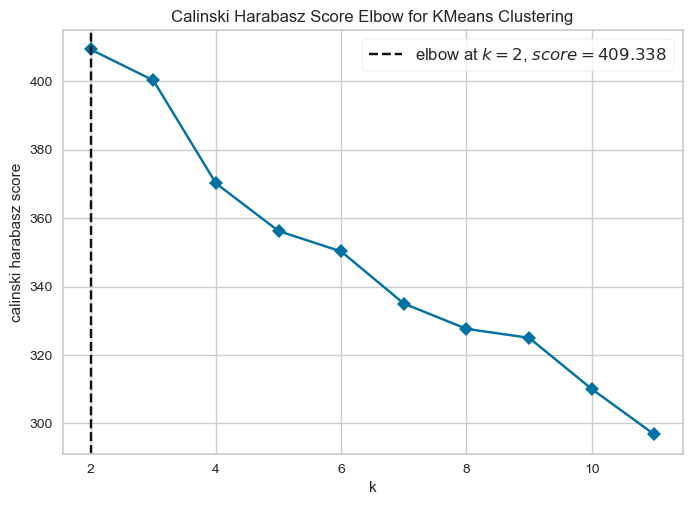

<AxesSubplot:title={'center':'Calinski Harabasz Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='calinski harabasz score'>

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

from yellowbrick.cluster import KElbowVisualizer

# Generate synthetic dataset with 8 random clusters
X=Feature_set.iloc[:,0:-1]
y=Feature_set.iloc[:,-1]

# Instantiate the clustering model and visualizer
model = KMeans()
visualizer = KElbowVisualizer(
    model, k=(2,12), metric='calinski_harabasz', timings=False
) #distortion same as Euclidean distance

visualizer.fit(X)        # Fit the data to the visualizer
visualizer.show() 

#### Distortion vs Calinski-Harabasz: Two Different Perspectives

| Metric | What it measures | Optimal K is at... |
|--------|-----------------|-------------------|
| **Distortion** | Average squared distance to centroid (lower = tighter clusters) | The **elbow** (bend in the curve) |
| **Calinski-Harabasz** | Ratio of between-cluster variance to within-cluster variance (higher = better separation) | The **peak** (highest point) |

> Using multiple metrics helps cross-validate your choice of K. If both metrics suggest the same K, you can be more confident in that choice.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

from yellowbrick.cluster import KElbowVisualizer

# Generate synthetic dataset with 8 random clusters
X=Feature_set.iloc[:,0:-1]
y_true=Feature_set.iloc[:,-1]
model = KMeans(n_clusters=2)
y_pred=model.fit_predict(X)

C:\Users\sit\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


#### Why K=2?

We set `n_clusters=2` here as a **demonstration**. The data actually contains 10 digit classes (0-9), so K=2 will force all 10 classes into just 2 groups -- the results will be poor. This is intentional: it shows what happens when you pick the **wrong K**.

Later in the Task section, you'll use the Elbow Method or Silhouette Coefficient to find the **right K** for your data.

## Performance Metrics

How do we know if our clustering is any good? We compare the predicted clusters against the true labels using these metrics:

| Metric | Range | What it tells you |
|--------|-------|-------------------|
| **Purity** | 0 to 1 | For each cluster, what fraction belongs to the most common true class? Higher = purer clusters. |
| **Rand Index** | 0 to 1 | What fraction of point-pairs are correctly grouped together or separated? |
| **Mutual Information** | 0 to 1 (normalised) | How much information do the clusters share with the true labels? |
| **Silhouette Coefficient** | -1 to 1 | How well-separated are the clusters? (Does NOT need true labels) |

> **Important:** Purity, Rand Index, and Mutual Information require ground truth labels -- they are **external** evaluation metrics. Silhouette Coefficient is an **internal** metric (no labels needed), making it useful when you don't know the true classes.

In [ ]:
from sklearn import metrics

def purity_score(y_true, y_pred):
    # compute contingency matrix (also called confusion matrix)
    contingency_matrix = metrics.cluster.contingency_matrix(y_true, y_pred)
    # return purity
    return np.sum(np.amax(contingency_matrix, axis=0)) / np.sum(contingency_matrix) 

#### How Purity Works -- A Small Example

Imagine we have 7 data points with true labels `[0,0,0,1,1,1,1]` and a clustering algorithm predicts `[0,0,0,1,1,0,1]`.

The **contingency matrix** counts how many points from each true class ended up in each predicted cluster:

|  | Predicted 0 | Predicted 1 |
|--|-------------|-------------|
| **True 0** | 3 | 0 |
| **True 1** | 1 | 3 |

**Purity calculation:**
1. For each predicted cluster, find the **maximum** count (the dominant true class)
   - Cluster 0: max(3, 1) = **3**
   - Cluster 1: max(0, 3) = **3**
2. Sum the maxima: 3 + 3 = **6**
3. Divide by total points: 6 / 7 = **0.857**

This means 85.7% of points were assigned to a cluster where they match the dominant class. Let's verify with the code below:

In [ ]:
from sklearn import metrics
y_true=[0,0,0,1,1,1,1]
y_pred=[0,0,0,1,1,0,1]
print(y_true)
print(y_pred)
contingency_matrix = metrics.cluster.contingency_matrix(y_true, y_pred)
print(contingency_matrix)

[0, 0, 0, 1, 1, 1, 1]
[0, 0, 0, 1, 1, 0, 1]
[[3 0]
 [1 3]]


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

         0.0       0.00      0.01      0.00       320
         1.0       0.02      0.06      0.03       327
         2.0       0.00      0.00      0.00       318
         3.0       0.00      0.00      0.00       328
         4.0       0.00      0.00      0.00       323
         5.0       0.00      0.00      0.00       325
         6.0       0.00      0.00      0.00       323
         7.0       0.00      0.00      0.00       320
         8.0       0.00      0.00      0.00       313
         9.0       0.00      0.00      0.00       321

    accuracy                           0.01      3218
   macro avg       0.00      0.01      0.00      3218
weighted avg       0.00      0.01      0.00      3218



C:\Users\sit\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\sit\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\sit\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


#### Why Are These Scores So Low?

The classification report shows nearly **0% precision and recall** for most classes. This is expected! Here's why:

- Our data has **10 true classes** (digits 0-9), but KMeans was set to only **K=2 clusters**.
- With only 2 predicted labels (0 and 1), KMeans cannot possibly distinguish 10 different digits.
- Most true classes have **no predicted samples** at all, so precision is undefined (set to 0.0).

> **Key takeaway:** The number of clusters K must be appropriate for the data. Using the Elbow Method or Silhouette Coefficient to select K is critical for getting meaningful results.

### Purity

In [ ]:
print(
    "purity_score: %0.3f"
    % purity_score(y_true, y_pred)
)

purity_score: 0.202


#### Interpreting the Purity Score

A purity of **~0.20** means only about 20% of data points are in a cluster dominated by their true class. This is very poor -- essentially random for 10 classes.

For comparison:
- **Purity = 1.0** -- Perfect clustering (each cluster contains only one class)
- **Purity = 0.5** -- Each cluster is half "correct"
- **Purity ~ 1/K** -- No better than random assignment

> **Limitation of purity:** Purity always increases as K increases. If K = N (one cluster per point), purity = 1.0 trivially. That's why we also need metrics like Mutual Information and Rand Index.

#### Quick Demo: Rand Index and Mutual Information

Since the Tasks ask you to compute these, here's how they work:

In [ ]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Small example
y_true_demo = [0, 0, 0, 1, 1, 1]
y_pred_good = [0, 0, 0, 1, 1, 1]  # perfect clustering
y_pred_bad  = [0, 1, 0, 1, 0, 1]  # random clustering

print("=== Perfect clustering ===")
print(f"  Adjusted Rand Index:        {adjusted_rand_score(y_true_demo, y_pred_good):.3f}")
print(f"  Normalised Mutual Info:     {normalized_mutual_info_score(y_true_demo, y_pred_good):.3f}")

print("\n=== Random clustering ===")
print(f"  Adjusted Rand Index:        {adjusted_rand_score(y_true_demo, y_pred_bad):.3f}")
print(f"  Normalised Mutual Info:     {normalized_mutual_info_score(y_true_demo, y_pred_bad):.3f}")

print("\nARI = 1.0 means perfect match, 0 means random, negative means worse than random")
print("NMI = 1.0 means perfect match, 0 means no shared information")

# Task 1
1. Read the "digitData2.csv" and "digitData3.csv" files and create KMeans clustering
2. Select the optimum k value using Silhouette Coefficient.
3. Find the mutual information and Rand Index between predicted and true class.

### Solution: Task 1

In [ ]:
# Step 1: Read data and prepare features
digit_two = pd.read_csv("data/digitData2.csv", header=None)
digit_three = pd.read_csv("data/digitData3.csv", header=None)

task1_data = pd.concat([digit_two, digit_three], join="inner")
cols = ["feature_" + str(i + 1) for i in range(task1_data.shape[1] - 1)]
cols.append("Target")
task1_data.columns = cols

X_task1 = task1_data.iloc[:, :-1]
y_true_task1 = task1_data.iloc[:, -1]

print("Shape:", task1_data.shape)
print("Unique classes:", sorted(y_true_task1.unique()))

In [ ]:
# Step 2: Find optimum K using Silhouette Coefficient
from sklearn.metrics import silhouette_score

silhouette_scores = []
K_range = range(2, 12)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_task1)
    score = silhouette_score(X_task1, labels)
    silhouette_scores.append(score)
    print(f"K={k:2d}  Silhouette Score: {score:.4f}")

best_k = K_range[np.argmax(silhouette_scores)]
print(f"\nBest K = {best_k} (highest Silhouette Score = {max(silhouette_scores):.4f})")

In [ ]:
# Visualise Silhouette Scores
plt.figure(figsize=(8, 4))
plt.plot(list(K_range), silhouette_scores, "o-")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Coefficient for Different K Values")
plt.xticks(list(K_range))
plt.axvline(x=best_k, color="r", linestyle="--", label=f"Best K={best_k}")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Step 3: KMeans with best K, compute Mutual Information and Rand Index
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

km_best = KMeans(n_clusters=best_k, n_init=10, random_state=42)
y_pred_task1 = km_best.fit_predict(X_task1)

ari = adjusted_rand_score(y_true_task1, y_pred_task1)
nmi = normalized_mutual_info_score(y_true_task1, y_pred_task1)
purity = purity_score(y_true_task1, y_pred_task1)

print(f"KMeans with K={best_k}")
print(f"  Adjusted Rand Index:       {ari:.4f}")
print(f"  Normalised Mutual Info:    {nmi:.4f}")
print(f"  Purity:                    {purity:.4f}")

<hr>

## DBSCAN 
**DBSCAN** - Density-Based Spatial Clustering of Applications with Noise. Finds core samples of high density and expands clusters from them. Good for data which contains clusters of similar density. [More details](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html)

### Key Parameters

| Parameter | What it controls | Effect |
|-----------|-----------------|--------|
| **`eps`** | Maximum distance between two points to be considered neighbours | Small eps -- many small clusters + noise; Large eps -- fewer, bigger clusters |
| **`min_samples`** | Minimum number of points to form a dense region (core point) | Small value -- more core points, more clusters; Large value -- stricter, fewer clusters |

**How DBSCAN classifies points:**
1. **Core point:** has at least `min_samples` neighbours within distance `eps`
2. **Border point:** within `eps` of a core point, but has fewer than `min_samples` neighbours
3. **Noise point:** not within `eps` of any core point -- labelled as **-1**

> Unlike KMeans, DBSCAN does **not** require you to specify the number of clusters in advance. It discovers them automatically based on data density. It can also identify **outliers** (noise points).

<hr>

In [ ]:
from sklearn.cluster import DBSCAN
X=Feature_set.iloc[:,0:-1]
y_true=Feature_set.iloc[:,-1]
model = DBSCAN(eps=0.3, min_samples=10)
y_pred=model.fit_predict(X)

print(
    "purity_score: %0.3f"
    % purity_score(y_true, y_pred)
)


purity_score: 0.102


#### Why is the DBSCAN Purity Even Lower?

Purity of **~0.10** is extremely low. This is because `eps=0.3` is **too small** for this 64-dimensional data -- almost no points are within 0.3 distance of each other.

As a result, DBSCAN likely labelled most points as **noise (-1)**, forming very few meaningful clusters.

> **Tip for tuning DBSCAN:**
> - Try plotting a **k-distance graph** (sorted distances to the k-th nearest neighbour) to find a reasonable `eps`.
> - A common heuristic: set `min_samples >= 2 x number_of_features`, but for high-dimensional data you may need to experiment.
> - High-dimensional data often needs **larger eps** values because distances tend to be larger in more dimensions (curse of dimensionality).

<hr>

# Task 2
1. Read the "digitData2.csv" and "digitData3.csv" files and create DBSCAN clustering
2. Find the optimum "eps" and "min_samples" value.
3. Find the mutual information and Rand Index between predicted and true class.

### Solution: Task 2

In [ ]:
# Step 1: Use a k-distance graph to find a reasonable eps
from sklearn.neighbors import NearestNeighbors

# Compute distance to the 5th nearest neighbour for each point
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_task1)
distances, _ = nn.kneighbors(X_task1)

# Sort the 5th-neighbour distances in ascending order
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.xlabel("Data Points (sorted)")
plt.ylabel("Distance to 5th Nearest Neighbour")
plt.title("K-Distance Graph (helps choose eps)")
plt.tight_layout()
plt.show()

print("Look for the 'elbow' in this plot -- that suggests a good eps value.")

In [ ]:
# Step 2: Try different eps and min_samples combinations
from sklearn.cluster import DBSCAN

eps_values = [5, 10, 15, 20, 25, 30]
min_samples_values = [3, 5, 10]

print(f"{'eps':>5} | {'min_samples':>11} | {'n_clusters':>10} | {'n_noise':>7} | {'Purity':>7} | {'ARI':>7} | {'NMI':>7}")
print("-" * 75)

best_ari = -1
best_params = {}

for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        y_pred_db = db.fit_predict(X_task1)
        
        n_clusters = len(set(y_pred_db)) - (1 if -1 in y_pred_db else 0)
        n_noise = list(y_pred_db).count(-1)
        
        if n_clusters >= 2:
            ari_db = adjusted_rand_score(y_true_task1, y_pred_db)
            nmi_db = normalized_mutual_info_score(y_true_task1, y_pred_db)
            pur_db = purity_score(y_true_task1, y_pred_db)
            print(f"{eps:5} | {ms:11} | {n_clusters:10} | {n_noise:7} | {pur_db:7.4f} | {ari_db:7.4f} | {nmi_db:7.4f}")
            
            if ari_db > best_ari:
                best_ari = ari_db
                best_params = {"eps": eps, "min_samples": ms}
        else:
            print(f"{eps:5} | {ms:11} | {n_clusters:10} | {n_noise:7} |  (too few clusters)")

print(f"\nBest params: eps={best_params.get('eps')}, min_samples={best_params.get('min_samples')}")

In [ ]:
# Step 3: DBSCAN with best parameters
db_best = DBSCAN(eps=best_params["eps"], min_samples=best_params["min_samples"])
y_pred_task2 = db_best.fit_predict(X_task1)

n_clusters = len(set(y_pred_task2)) - (1 if -1 in y_pred_task2 else 0)
n_noise = list(y_pred_task2).count(-1)

ari = adjusted_rand_score(y_true_task1, y_pred_task2)
nmi = normalized_mutual_info_score(y_true_task1, y_pred_task2)
purity = purity_score(y_true_task1, y_pred_task2)

print(f"DBSCAN with eps={best_params['eps']}, min_samples={best_params['min_samples']}")
print(f"  Number of clusters found:  {n_clusters}")
print(f"  Number of noise points:    {n_noise}")
print(f"  Adjusted Rand Index:       {ari:.4f}")
print(f"  Normalised Mutual Info:    {nmi:.4f}")
print(f"  Purity:                    {purity:.4f}")

<hr>

## Hierarchy
**Hierarchical clustering** is a general family of clustering algorithms that build nested clusters by merging or splitting them successively.[More details](\url{https://scikit-learn.org/stable/modules/clustering.html#hierarchical-clustering})
<hr>

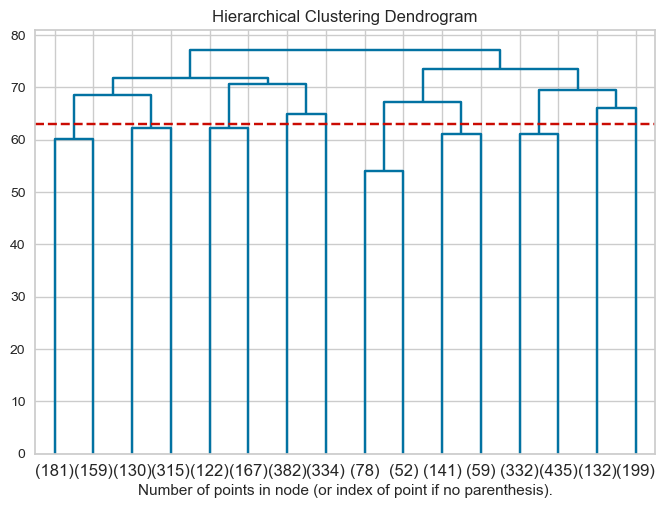

In [ ]:
import numpy as np

from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering


def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)


X=Feature_set.iloc[:,0:-1]
y_true=Feature_set.iloc[:,-1]
# setting distance_threshold=0 ensures we compute the full tree.
model = AgglomerativeClustering(distance_threshold=0,linkage="complete",n_clusters=None)
model = model.fit(X)

plt.title("Hierarchical Clustering Dendrogram")
# plot the top three levels of the dendrogram
plot_dendrogram(model, truncate_mode="level", p=3)
plt.axhline(y=63, color='r', linestyle='--')
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show()

#### How to Read a Dendrogram

A **dendrogram** is a tree diagram that shows the order in which clusters were merged:

- **X-axis:** individual data points (or groups of points)
- **Y-axis:** the distance at which two clusters were merged
- **Height of each horizontal line:** indicates how "far apart" the two merged clusters were

**How to choose the number of clusters:**
1. Draw a **horizontal line** across the dendrogram (the red dashed line in the plot below)
2. Count how many vertical lines the horizontal line crosses -- that's your number of clusters
3. Choose the height where there's the **largest vertical gap** (longest branches before the next merge)

> The `linkage` parameter controls how distances between clusters are computed:
> - `"complete"` -- maximum distance between any pair of points in two clusters (tends to produce compact clusters)
> - `"single"` -- minimum distance (can create elongated chains)
> - `"average"` -- average distance (balanced approach)
> - `"ward"` -- minimises total within-cluster variance (similar to KMeans objective)

In [ ]:
model = AgglomerativeClustering( linkage="complete",n_clusters=2)

y_pred = model.fit_predict(X)
print(
    "purity_score: %0.3f"
    % purity_score(y_true, y_pred)
)


purity_score: 0.198


#### Interpreting the Result

Purity of **~0.20** is again low, for the same reason as KMeans -- we forced `n_clusters=2` on data with 10 true classes.

> **Comparing the three algorithms so far:**
> 
> | Algorithm | Purity (K=2) | Notes |
> |-----------|-------------|-------|
> | KMeans | ~0.20 | Fast, needs K specified |
> | DBSCAN | ~0.10 | Automatic K, but eps was too small |
> | Hierarchical | ~0.20 | Flexible, but slow on large data |
> 
> All three perform poorly here because either K is wrong or parameters need tuning. In the Tasks below, you'll find better parameters!

<hr>

# Task 3
1. Read the "digitData2.csv" and "digitData3.csv" files and create Hierarchy clustering
2. Find the optimum "n_clusters" using "manhattan" distance.
3. Find the mutual information and Rand Index between predicted and true class.

### Solution: Task 3

Note: When using `metric="manhattan"`, `linkage` must be `"complete"`, `"average"`, or `"single"` (cannot use `"ward"` with non-Euclidean distances).

In [ ]:
# Step 1: Try different n_clusters with manhattan distance
from sklearn.cluster import AgglomerativeClustering

cluster_range = range(2, 12)
results = []

print(f"{'n_clusters':>10} | {'Silhouette':>10} | {'ARI':>7} | {'NMI':>7} | {'Purity':>7}")
print("-" * 60)

for n in cluster_range:
    hc = AgglomerativeClustering(
        n_clusters=n, metric="manhattan", linkage="complete"
    )
    y_pred_hc = hc.fit_predict(X_task1)
    
    sil = silhouette_score(X_task1, y_pred_hc)
    ari_hc = adjusted_rand_score(y_true_task1, y_pred_hc)
    nmi_hc = normalized_mutual_info_score(y_true_task1, y_pred_hc)
    pur_hc = purity_score(y_true_task1, y_pred_hc)
    
    results.append({"n": n, "sil": sil, "ari": ari_hc, "nmi": nmi_hc, "pur": pur_hc})
    print(f"{n:10} | {sil:10.4f} | {ari_hc:7.4f} | {nmi_hc:7.4f} | {pur_hc:7.4f}")

best_n = max(results, key=lambda x: x["sil"])["n"]
print(f"\nBest n_clusters = {best_n} (highest Silhouette Score)")

In [ ]:
# Step 2: Hierarchical clustering with best n_clusters
hc_best = AgglomerativeClustering(
    n_clusters=best_n, metric="manhattan", linkage="complete"
)
y_pred_task3 = hc_best.fit_predict(X_task1)

ari = adjusted_rand_score(y_true_task1, y_pred_task3)
nmi = normalized_mutual_info_score(y_true_task1, y_pred_task3)
purity = purity_score(y_true_task1, y_pred_task3)

print(f"Hierarchical Clustering with n_clusters={best_n}, metric='manhattan', linkage='complete'")
print(f"  Adjusted Rand Index:       {ari:.4f}")
print(f"  Normalised Mutual Info:    {nmi:.4f}")
print(f"  Purity:                    {purity:.4f}")

<hr>

# End of Week 3
<hr>